LightGBMでそれっぽく実装してみたnotebookを公開します。

- CV: 0.6856 / LB: 0.6758
- train/valid
   - StratifiedGroupKFold
   - employee_idでgroup, targetでstartified

特徴量エンジニアリングはだいぶ適当なので、改善の余地がかなりあると思います。

In [ ]:
# ====================================================
# Library
# ====================================================
import os
import gc
import warnings
warnings.filterwarnings('ignore')
import random
from scipy import sparse as sp
import numpy as np
import pandas as pd
import polars as pl
from glob import glob
from pathlib import Path
import joblib
import pickle
import itertools
from tqdm.auto import tqdm
from datetime import datetime


import torch
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split, GroupKFold, StratifiedGroupKFold
from sklearn.metrics import log_loss, roc_auc_score, matthews_corrcoef, f1_score
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import TruncatedSVD, NMF
import lightgbm as lgb
import xgboost as xgb
# from catboost import Pool, CatBoostRegressor, CatBoostClassifier
import time

# import implicit
import scipy.stats as stats
from scipy.sparse import coo_matrix
from pprint import pprint

from abc import ABC, abstractmethod


In [ ]:
# ====================================================
# Configurations
# ====================================================
class CFG:
    VER = 0
    AUTHOR = 'nogawanogawa'
    COMPETITION = 'atmacup20'
    MAIN_PATH = 'G:\マイドライブ\competitions\atma_udemy\0_sample' ### パスを適宜変更
    DATA_PATH = Path(f'{MAIN_PATH}/data')
    OUTPUT_PATH = Path(f'{MAIN_PATH}/output')
    MODEL_PATH = Path(f'{MAIN_PATH}/model')
    PREPROCESSED_DATA_PATH = Path(f'{MAIN_PATH}/preprocessed_data')
    OOF_DATA_PATH = Path(f'{MAIN_PATH}/oof')
    MODEL_DATA_PATH = Path(f'{MAIN_PATH}/models')

    # USE_GPU = torch.cuda.is_available()
    SEED = 42
    N_SPLIT = 4
    metric = 'auc'
    metric_maximize_flag = True

    num_boost_round = 2500
    early_stopping_round = 50
    verbose = 100

    lgb_params = {
        'boosting_type': 'gbdt',
        'objective': 'binary',
        'metric': 'auc', # 'binary_logloss',
        'n_estimators': 10000,
        "max_depth": 15,
        "num_leaves": 500,
        'feature_fraction': 0.8,
        'bagging_freq': 1,
        'learning_rate': 0.05,
        'bagging_fraction': 0.8,
        'num_leaves': 6,
        'random_state': SEED,
        "colsample_bytree": 0.9,
        "colsample_bynode": 0.6,
        "lambda_l1": 3.5,
        "lambda_l2": 1.5,
        "min_data_in_leaf": 50,
        'device':'cpu',
    }

    xgb_params = {
        'tree_method': "gpu_hist",
        'objective': 'binary:logistic',
        'eval_metric': 'auc', # 'logloss',
        'n_estimators':10000,
        'early_stopping_rounds': 50,
        'learning_rate': 0.05,
        'max_depth': 6,
        'random_state': SEED,
        'gamma':0.1,
        'subsample':0.8,
        'colsample_bytree':0.3,
        'min_child_weight':3,
    }

    cat_params = {
        'loss_function': 'Logloss',
        'eval_metric': 'AUC', #
        'learning_rate': 0.05,
        'iterations': num_boost_round,
        'depth': 3,
        'random_seed': SEED,
    }

In [ ]:
DATA_DIR = CFG.DATA_PATH

# random seedを固定
def fix_seed(seed):
    # random
    random.seed(seed)
    # Numpy
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

fix_seed(CFG.SEED)

## dataload

In [ ]:
#@title データロード

class DataLoader(ABC):
    """
    データローダーの抽象クラス
    """

    def __init__(self):
        """
        初期化メソッド
        """
        pass

    @abstractmethod
    def get(self) -> pl.DataFrame:
        """
        データを取得する抽象メソッド
        サブクラスで実装する必要があります
        """
        pass


In [ ]:
class TrainLoader(DataLoader):
    """train.csvファイルを読み込むためのDataLoader"""

    def __init__(self, file_path: str = "data/train.csv"):
        super().__init__()
        self.file_path = file_path
        self.df = pl.read_csv(self.file_path)

        column_mapping = {
            "社員番号": "employee_id",
        }

        # カラム名を変更
        self.df = self.df.rename(column_mapping)

        # response_mapping = {
        #     "コーポレート管理部門/技術・データ・BPR": "corporate_ops",
        #     "事業企画・開発・研究": "business_dev",
        #     "マーケティング": "marketing",
        #     "営業": "sales",
        #     "コンテンツ・サービス・デザイン": "content_design",
        #     "プロダクトマネジメント": "product_mgmt",
        # }

        # self.df = self.df.with_columns(
        #     pl.col("category").replace_strict(response_mapping)
        # )

    def get(self):
        return self.df


In [ ]:
class TestLoader(DataLoader):
    """test.csvファイル用のDataLoader"""

    def __init__(self, file_path: str = "data/train.csv"):
        super().__init__()
        self.file_path = file_path
        self.df = pl.read_csv(self.file_path)

        column_mapping = {
            "社員番号": "employee_id",
        }

        # カラム名を変更
        self.df = self.df.rename(column_mapping)

        # response_mapping = {
        #     "コーポレート管理部門/技術・データ・BPR": "corporate_ops",
        #     "事業企画・開発・研究": "business_dev",
        #     "マーケティング": "marketing",
        #     "営業": "sales",
        #     "コンテンツ・サービス・デザイン": "content_design",
        #     "プロダクトマネジメント": "product_mgmt",
        # }

        # self.df = self.df.with_columns(
        #     pl.col("category").replace_strict(response_mapping)
        # )

    def get(self):
        return self.df


In [ ]:
class CareerLoader(DataLoader):
    """career.csvファイル用のDataLoader"""

    def __init__(self, file_path: str = "data/career.csv"):
        super().__init__()
        self.file_path = file_path
        self.df = pl.read_csv(self.file_path)

        column_mapping = {
            "社員番号": "employee_id",
            "自分の能力を発揮できる仕事上の得意分野が見つかっている\n": "found_strengths",
            "自分はどんな仕事をやりたいのか明らかである      \n": "clear_job_interest",
            "自分は何を望んで今の仕事をしているのかわかっている\n": "know_job_purpose",
            "自分なりの職業的な生き方に関する目標・目的がはっきりしている\n": "clear_career_goals",
            "自分のこれからのキャリアには、あまり関心がない\n": "low_career_interest",
            "これからのキャリアを、より充実したものにしたいと強く思う\n": "strong_career_desire",
            "キャリア設計（職業生活の設計）は、自分にとって重要な課題である\n": "career_design_important",
            "これからのキャリアをどう歩むべきか、あまり考えていない\n": "not_thinking_future_career",
            "納得いくキャリアを歩めるかどうかは、自分の責任だと思う\n": "career_satisfaction_my_responsibility",
            "キャリア形成は、自分自身の責任である\n": "career_dev_my_responsibility",
            "納得いくキャリアを歩めない原因の大半は周囲の環境にある\n": "blame_env_for_unsat_career",
            "キャリアは周りの環境によって決められていくものだと思う\n": "career_shaped_by_env",
            "新しい環境や状況にも、わりあい早くなじんで対応している": "adapt_new_env_quickly",
            "職場環境の変化に対して自分なりに考えて対応している": "respond_to_work_env_changes",
            "新しい職場に移ってもすぐに自分らしさを発揮している": "show_self_in_new_workplace",
            "職場の制度や仕事が変わってもすぐ対応している": "adapt_to_work_changes",
            "自分の職種・業界分野における最新動向を常に情報収集している": "track_industry_trends",
            "仕事のために新しいことをいろいろ勉強している": "study_new_for_work",
            "社会・経済の動きや成り行きに関する情報を、積極的に収集している": "follow_social_econ_trends",
            "新しい知識・技術を積極的に学ぶように努めている": "learn_new_tech",
            "新しい人間関係が構築できるように、社内外の活動に積極的に参加している": "build_relations_actively",
            "仕事と直接関係ない人とも積極的に交流するようにしている": "interact_beyond_work",
            "新しいネットワークづくりに常に取り組んでいる": "build_new_networks",
            "自分の満足感を高めるように、仕事のやり方を工夫している": "improve_work_for_satisfaction",
            "常に自発的に仕事を行っている": "work_proactively",
            "自分の価値観やポリシーを持って仕事に取り組んでいる": "work_with_values",
            "仕事の進め方や企画を立てる上で、今までの延長上のやり方ではなく、自分なりの発想を持って取り組んでいる": "creative_work_planning",
            "少人数チームで協力してタスクを完遂できる": "small_team_collab",
            "メンバー全員のアイデアを取り入れて成果物を作れる": "integrate_team_ideas",
            "同僚や上司に向けて口頭でプレゼンテーションができる": "oral_presentation",
            "スライドや動画などのデジタル資料を用いて情報を共有できる": "share_info_digitally",
            "異なる視点を比較して最適な解決策を選べる": "compare_views_find_solution",
            "正解が一つでない問題に対して解決策を導き出せる": "solve_ambiguous_problems",
            "複数のアイデアを試行し改善を重ねられる": "iterate_ideas_improve",
            "困難な業務課題に対して独自の解決策を考案できる": "create_unique_solutions",
            "自分の進捗をモニタリングし計画を柔軟に調整できる": "monitor_and_adjust_plan",
            "フィードバックを受けて自ら仕事を改善できる": "use_feedback_to_improve",
            "業務データを可視化し\xa0BI\xa0ダッシュボードで意思決定に活用できる": "use_bi_for_decision",
            "RPA／ノーコードツールで反復的な業務フローを自動化できる": "automate_with_rpa",
            "生成\xa0AI\xa0や機械学習モデルを業務改善に活用できる": "use_ai_ml_for_improvement",
            "クラウド環境のアクセス権限を監査し情報保護を徹底できる": "audit_cloud_security",
            "デジタルマーケティング施策（SNS\xa0広告等）をデータで最適化できる": "optimize_digital_marketing",
            "顧客・市場データを用いて新商品・サービス企画を立案できる": "plan_products_with_data",
            "クラウド／DevOps\xa0環境を構築し\xa0IaC\xa0で継続的デプロイを管理できる": "manage_devops_with_iac",
            "デジタルツインや\xa0IoT\xa0データを用いたサプライチェーン最適化を提案・実装できる": "optimize_supply_with_iot",
        }

        # カラム名を変更
        self.df = self.df.rename(column_mapping)

        response_mapping = {
            "1 全くそう思わない／全く当てはまらない": 1,
            "2 あまりそう思わない／あまり当てはまらない": 2,
            "3 どちらとも言えない": 3,
            "4 そう思う／当てはまる": 4,
            "5 強くそう思う／とても当てはまる ": 5,
            "5 強くそう思う／とても当てはまる": 5,
        }

        target_cols = [col for col in self.df.columns if col != "employee_id"]

        # 各列にマッピングを適用して更新
        for col in target_cols:
            self.df = self.df.with_columns(
                pl.col(col).replace_strict(response_mapping)
            )

    def get(self):
        return self.df


In [ ]:
class DXLoader(DataLoader):
    """dx.csvファイル用のDataLoader"""

    def __init__(self, file_path: str = "data/dx.csv"):
        super().__init__()
        self.file_path = file_path
        self.df = pl.read_csv(self.file_path)

        column_mapping = {
            "社員番号": "employee_id",
            "研修実施日": "training_date",
            "研修カテゴリ": "training_category",
            "研修名": "training_name",
        }

        self.df = self.df.rename(column_mapping)

        self.df = self.df.with_columns(
            pl.col("training_date").str.strptime(pl.Date, "%F %T", strict=False),
        )

        enc = LabelEncoder()
        self.df = self.df.with_columns(
            pl.col("training_category").map_batches(enc.fit_transform)
        )

        enc = LabelEncoder()
        self.df = self.df.with_columns(
            pl.col("training_name").map_batches(enc.fit_transform)
        )

    def get(self):
        return self.df

dx = DXLoader(DATA_DIR / "dx.csv").get()
dx

employee_id,training_date,training_category,training_name
str,date,i64,i64
"""-2Sq3E0WkZj8pL7jxdL3Cg==""",2024-04-15,9,34
"""-2Sq3E0WkZj8pL7jxdL3Cg==""",2024-04-16,9,38
"""-5W_JQCSTAYe2gGJMuT4_w==""",2023-04-20,9,52
"""-5W_JQCSTAYe2gGJMuT4_w==""",2023-04-20,9,53
"""-5W_JQCSTAYe2gGJMuT4_w==""",2024-04-15,9,40
…,…,…,…
"""zuplFpzBoM4c1dFy5HPXqg==""",2024-10-04,6,26
"""zuplFpzBoM4c1dFy5HPXqg==""",2024-10-23,6,24
"""zxPKKLM85QljzRfp0yisow==""",2023-08-23,6,90


In [ ]:
class HRLoader(DataLoader):
    """hr.csvファイル用のDataLoader"""

    def __init__(self, file_path: str = "data/dx.csv"):
        super().__init__()
        self.file_path = file_path
        self.df = pl.read_csv(self.file_path)

        column_mapping = {
            "社員番号": "employee_id",
            "カテゴリ": "hr_training_category",
            "研修名": "hr_training_name",
            "実施日": "hr_training_date",
        }

        self.df = self.df.rename(column_mapping)

        self.df = self.df.with_columns(
            pl.col("hr_training_date").str.split(",")  # カンマで分割してリストに
        ).explode("hr_training_date")  # リストを縦に展開

        # TODO: 日付のフォーマットが複数あるので、coalesceでフォーマットを変換
        # self.df = self.df.with_columns(
        #     pl.col("hr_training_date").map_elements(extract_dates_polars, return_dtype=pl.List(pl.String)).alias("hr_training_date")
        # ).explode("hr_training_date")

        self.df = self.df.with_columns([
            pl.coalesce([
                pl.col("hr_training_date").str.strptime(pl.Date, "%Y/%m/%d", strict=False),
                pl.col("hr_training_date").str.strptime(pl.Date, "%Y-%m-%d %H:%M:%S", strict=False)
            ])
        ])

        enc = LabelEncoder()
        self.df = self.df.with_columns(
            pl.col("hr_training_category").map_batches(enc.fit_transform)
        )

        enc = LabelEncoder()
        self.df = self.df.with_columns(
            pl.col("hr_training_name").map_batches(enc.fit_transform)
        )


    def get(self):
        return self.df


In [ ]:
class OvertimeWorkLoader(DataLoader):
    """overtime_work_by_month.csvファイル用のDataLoader"""

    def __init__(self, file_path: str = "data/overtime_work_by_month.csv"):
        super().__init__()
        self.file_path = file_path
        self.df = pl.read_csv(self.file_path)

        column_mapping = {
            "社員番号": "employee_id",
        }

        self.df = self.df.rename(column_mapping)

    def get(self):
        return self.df


In [ ]:
class PositionHistoryLoader(DataLoader):
    """position_history.csvファイル用のDataLoader"""

    def __init__(self, file_path: str = "data/position_history.csv"):
        super().__init__()
        self.file_path = file_path
        self.df = pl.read_csv(self.file_path)

        column_mapping = {
            "社員番号": "employee_id",
            "year": "year",
            "勤務区分": "work_category",
            "役職": "position"
        }

        self.df = self.df.rename(column_mapping)

        self.df = self.df.with_columns(
            pl.col("work_category").map_batches(LabelEncoder().fit_transform)
        )

        self.df = self.df.with_columns(
            pl.col("position").map_batches(LabelEncoder().fit_transform)
        )

    def get(self):
        return self.df


In [ ]:
class UdemyActivityLoader(DataLoader):
    """udemy_activity.csvファイル用のDataLoader"""

    def __init__(self, file_path: str = "data/udemy_activity.csv"):
        super().__init__()
        self.file_path = file_path
        self.df = pl.read_csv(self.file_path)

        column_mapping = {
            "社員番号": "employee_id",
            "コースID": "course_id",
            "コースタイトル": "course_title",
            "レクチャーもしくはクイズ": "lecture_or_quiz",
            "レクチャー/クイズID": "lecture_or_quiz_id",
            "レクチャー/クイズの題名": "lecture_or_quiz_title",
            "開始日": "start_date",
            "終了日": "end_date",
            "推定完了率%": "estimated_completion_rate_percent",
            "最終結果（クイズの場合）": "final_result_if_quiz",
            "マーク済み修了": "marked_as_completed",
            "コースカテゴリー": "course_category",
        }

        self.df = self.df.rename(column_mapping)

        # カテゴリ変数
        self.df = self.df.with_columns(
            pl.col("lecture_or_quiz_id").cast(pl.Utf8).cast(pl.Utf8)
        )

        self.df = self.df.with_columns(
            [
                pl.coalesce(
                    [
                        pl.col("start_date").str.strptime(
                            pl.Datetime, "%Y/%m/%d %H:%M", strict=False
                        )
                    ]
                )
            ]
        ).with_columns(
            [
                pl.coalesce(
                    [
                        pl.col("end_date").str.strptime(
                            pl.Datetime, "%Y/%m/%d %H:%M", strict=False
                        )
                    ]
                )
            ]
        )

        self.df = self.df.with_columns(
            pl.col("course_title").map_batches(LabelEncoder().fit_transform)
        )

        self.df = self.df.with_columns(
            pl.col("lecture_or_quiz_title").map_batches(LabelEncoder().fit_transform)
        )

        self.df = self.df.with_columns(
            pl.col("course_category").map_batches(LabelEncoder().fit_transform)
        )

    def get(self):
        return self.df


In [ ]:
# Load
train = TrainLoader(DATA_DIR / "train.csv").get()
test = TestLoader(DATA_DIR / "test.csv").get()
career = CareerLoader(DATA_DIR / "career.csv").get()
dx = DXLoader(DATA_DIR / "dx.csv").get()
hr = HRLoader(DATA_DIR / "hr.csv").get()
overtime_work = OvertimeWorkLoader(DATA_DIR / "overtime_work_by_month.csv").get()
position_history = PositionHistoryLoader(DATA_DIR / "position_history.csv").get()
udemy_activity = UdemyActivityLoader(DATA_DIR / "udemy_activity.csv").get()

In [ ]:
udemy_activity

employee_id,course_id,course_title,lecture_or_quiz,lecture_or_quiz_id,lecture_or_quiz_title,start_date,end_date,estimated_completion_rate_percent,final_result_if_quiz,marked_as_completed,course_category
str,i64,i64,str,str,i64,datetime[μs],datetime[μs],f64,f64,bool,i64
"""-1sqs0GXzpPJuAVKHUUFgg==""",4615016,3012,"""Quiz""","""5528090""",62746,2022-04-11 10:10:00,2022-04-11 10:10:00,100.0,0.0,true,270
"""-1sqs0GXzpPJuAVKHUUFgg==""",4615016,3012,"""Quiz""","""5528090""",62746,2022-04-11 10:11:00,2022-04-11 10:11:00,100.0,100.0,true,270
"""-1sqs0GXzpPJuAVKHUUFgg==""",4615016,3012,"""Quiz""","""5528100""",62746,2022-04-11 10:26:00,2022-04-11 10:26:00,100.0,0.0,true,270
"""-1sqs0GXzpPJuAVKHUUFgg==""",4615016,3012,"""Quiz""","""5528100""",62746,2022-04-11 10:27:00,2022-04-11 10:27:00,100.0,100.0,true,270
"""-1sqs0GXzpPJuAVKHUUFgg==""",4615016,3012,"""Quiz""","""5528102""",62746,2022-04-11 10:21:00,2022-04-11 10:21:00,100.0,100.0,true,270
…,…,…,…,…,…,…,…,…,…,…,…
"""zxY0Eflwm1tYj1Wt6vo_1g==""",5264112,3012,"""Video_lecture""","""37311144""",62746,2023-06-14 09:56:00,2023-06-14 09:56:00,100.0,null,true,270
"""zxY0Eflwm1tYj1Wt6vo_1g==""",5264112,3012,"""Video_lecture""","""37311150""",62746,2023-06-14 09:57:00,2023-06-14 09:57:00,100.0,null,true,270
"""zxY0Eflwm1tYj1Wt6vo_1g==""",6098315,3012,"""Video_lecture""","""45012691""",62746,2024-09-27 15:39:00,2024-09-27 16:17:00,100.0,null,true,270


In [ ]:
# input session
def attach_fold(df) -> pl.DataFrame:

  # どのfoldも同じくらいpositive例が出現するようにstratifiedにする
  sgkf = StratifiedGroupKFold(n_splits=CFG.N_SPLIT)

  folds = [
      df[test_index].select("employee_id").with_columns(
          pl.lit(i).alias("fold")
      ) for i, (train_index, test_index) in enumerate(sgkf.split(df, df["target"], df["employee_id"]))
  ]

  return df.join(pl.concat(folds), on="employee_id", how="left")

train = attach_fold(train)

In [ ]:
#@title Feature engineering

dx_training_category = dx[["employee_id", "training_category", "training_date"]].pivot("training_category", index="employee_id", aggregate_function="len")
prefix = "dx_training_category_"
dx_training_category = dx_training_category.rename({col: prefix + col for col in dx_training_category.columns if col != "employee_id"})

dx_training_name = dx[["employee_id", "training_name", "training_date"]].pivot("training_name", index="employee_id", aggregate_function="len")
prefix = "dx_training_name_"
dx_training_name = dx_training_name.rename({col: prefix + col for col in dx_training_name.columns if col != "employee_id"})


In [ ]:

hr_training_category = hr[["employee_id", "hr_training_category", "hr_training_date"]].pivot("hr_training_category", index="employee_id", aggregate_function="len")
prefix = "hr_training_category_"
hr_training_category = hr_training_category.rename({col: prefix + col for col in hr_training_category.columns if col != "employee_id"})

hr_training_name = hr[["employee_id", "hr_training_name", "hr_training_date"]].pivot("hr_training_name", index="employee_id", aggregate_function="len")
prefix = "hr_training_name_"
hr_training_name = hr_training_name.rename({col: prefix + col for col in hr_training_name.columns if col != "employee_id"})


In [ ]:
overtime_work_df = overtime_work.group_by("employee_id").agg([
  pl.col("hours").mean().alias("hours_mean"),
  pl.col("hours").min().alias("hours_min"),
  pl.col("hours").max().alias("hours_max"),
  pl.col("hours").std().alias("hours_std"),
  pl.col("hours").count().alias("hours_count"),
])

In [ ]:
position_history_work_category = position_history[["employee_id", "work_category", "year"]].pivot("work_category", index="employee_id", aggregate_function="len")
prefix = "position_history_work_category_"
position_history_work_category = position_history_work_category.rename({col: prefix + col for col in position_history_work_category.columns if col != "employee_id"})

position_history_position = position_history[["employee_id", "position", "year"]].pivot("position", index="employee_id", aggregate_function="len")
prefix = "position_history_position_"
position_history_position = position_history_position.rename({col: prefix + col for col in position_history_position.columns if col != "employee_id"})


In [ ]:
udemy_activity_numerical = udemy_activity.group_by("employee_id").agg([
  # estimated_completion_rate_percent
  pl.col("estimated_completion_rate_percent").mean().alias("estimated_completion_rate_percent_mean"),
  pl.col("estimated_completion_rate_percent").min().alias("estimated_completion_rate_percent_min"),
  pl.col("estimated_completion_rate_percent").max().alias("estimated_completion_rate_percent_max"),
  pl.col("estimated_completion_rate_percent").std().alias("estimated_completion_rate_percent_std"),
  pl.col("estimated_completion_rate_percent").count().alias("estimated_completion_rate_percent_count"),

  # final_result_if_quiz
  pl.col("final_result_if_quiz").mean().alias("final_result_if_quiz_mean"),
  pl.col("final_result_if_quiz").min().alias("final_result_if_quiz_min"),
  pl.col("final_result_if_quiz").max().alias("final_result_if_quiz_max"),
  pl.col("final_result_if_quiz").std().alias("final_result_if_quiz_std"),
  pl.col("final_result_if_quiz").count().alias("final_result_if_quiz_count"),

  # marked_as_completed
  pl.col("marked_as_completed").mean().alias("marked_as_completed_mean"),
  pl.col("marked_as_completed").min().alias("marked_as_completed_min"),
  pl.col("marked_as_completed").max().alias("marked_as_completed_max"),
  pl.col("marked_as_completed").std().alias("marked_as_completed_std"),
  pl.col("marked_as_completed").count().alias("marked_as_completed_count"),
])


udemy_activity_course_category = udemy_activity[["employee_id", "course_category", "start_date"]].pivot("course_category", index="employee_id", aggregate_function="len")
prefix = "udemy_activity_course_category_"
udemy_activity_course_category = udemy_activity_course_category.rename({col: prefix + col for col in udemy_activity_course_category.columns if col != "employee_id"})


udemy_activity_lecture_or_quiz = udemy_activity[["employee_id", "lecture_or_quiz", "start_date"]].pivot("lecture_or_quiz", index="employee_id", aggregate_function="len")
prefix = "udemy_activity_lecture_or_quiz_"
udemy_activity_lecture_or_quiz = udemy_activity_lecture_or_quiz.rename({col: prefix + col for col in udemy_activity_lecture_or_quiz.columns if col != "employee_id"})


# udemy_activity_course_id = udemy_activity[["employee_id", "course_id", "start_date"]].pivot("course_id", index="employee_id", aggregate_function="len")


In [ ]:
udemy_activity_lecture_or_quiz

employee_id,udemy_activity_lecture_or_quiz_Quiz,udemy_activity_lecture_or_quiz_Video_lecture,udemy_activity_lecture_or_quiz_Other_lecture
str,u32,u32,u32
"""-1sqs0GXzpPJuAVKHUUFgg==""",11,21,null
"""-2Sq3E0WkZj8pL7jxdL3Cg==""",2,189,3
"""-4jh26kLzkU8JFQwdeQU9w==""",null,2,null
"""-4taxxVbT1nU-J5fHWmDfQ==""",6,297,13
"""-5W_JQCSTAYe2gGJMuT4_w==""",1,132,13
…,…,…,…
"""zow_7-qpjek7cWzX4-70fg==""",null,220,4
"""zs-xCihHPKBivyOIXncfzQ==""",4,121,null
"""zuplFpzBoM4c1dFy5HPXqg==""",null,60,2


In [ ]:

train_df = train.join(
    career, on="employee_id", how="left"
).join(
    dx_training_category, on="employee_id", how="left"
).join(
    dx_training_name, on="employee_id", how="left"
).join(
    hr_training_category, on="employee_id", how="left"
).join(
    hr_training_name, on="employee_id", how="left"
).join(
    overtime_work_df, on="employee_id", how="left"
).join(
    position_history_work_category, on="employee_id", how="left"
).join(
    position_history_position, on="employee_id", how="left"
).join(
    udemy_activity_numerical, on="employee_id", how="left"
).join(
    udemy_activity_course_category, on="employee_id", how="left"
).join(
    udemy_activity_lecture_or_quiz, on="employee_id", how="left"
# ).join(
#     udemy_activity_course_id, on="employee_id", how="left"
)

assert len(train) == len(train_df)

In [ ]:
test_df = test.join(
    career, on="employee_id", how="left"
).join(
    dx_training_category, on="employee_id", how="left"
).join(
    dx_training_name, on="employee_id", how="left"
).join(
    hr_training_category, on="employee_id", how="left"
).join(
    hr_training_name, on="employee_id", how="left"
).join(
    overtime_work_df, on="employee_id", how="left"
).join(
    position_history_work_category, on="employee_id", how="left"
).join(
    position_history_position, on="employee_id", how="left"
).join(
    udemy_activity_numerical, on="employee_id", how="left"
).join(
    udemy_activity_course_category, on="employee_id", how="left"
).join(
    udemy_activity_lecture_or_quiz, on="employee_id", how="left"
# ).join(
#     udemy_activity_course_id, on="employee_id", how="left"
)

assert len(test) == len(test_df)

In [ ]:
train_df

employee_id,category,target,fold,found_strengths,clear_job_interest,know_job_purpose,clear_career_goals,low_career_interest,strong_career_desire,career_design_important,not_thinking_future_career,career_satisfaction_my_responsibility,career_dev_my_responsibility,blame_env_for_unsat_career,career_shaped_by_env,adapt_new_env_quickly,respond_to_work_env_changes,show_self_in_new_workplace,adapt_to_work_changes,track_industry_trends,study_new_for_work,follow_social_econ_trends,learn_new_tech,build_relations_actively,interact_beyond_work,build_new_networks,improve_work_for_satisfaction,work_proactively,work_with_values,creative_work_planning,small_team_collab,integrate_team_ideas,oral_presentation,share_info_digitally,compare_views_find_solution,solve_ambiguous_problems,…,udemy_activity_course_category_305,udemy_activity_course_category_207,udemy_activity_course_category_223,udemy_activity_course_category_243,udemy_activity_course_category_254,udemy_activity_course_category_219,udemy_activity_course_category_6,udemy_activity_course_category_2,udemy_activity_course_category_239,udemy_activity_course_category_173,udemy_activity_course_category_181,udemy_activity_course_category_98,udemy_activity_course_category_167,udemy_activity_course_category_252,udemy_activity_course_category_183,udemy_activity_course_category_224,udemy_activity_course_category_142,udemy_activity_course_category_109,udemy_activity_course_category_278,udemy_activity_course_category_7,udemy_activity_course_category_217,udemy_activity_course_category_45,udemy_activity_course_category_68,udemy_activity_course_category_84,udemy_activity_course_category_164,udemy_activity_course_category_155,udemy_activity_course_category_92,udemy_activity_course_category_230,udemy_activity_course_category_171,udemy_activity_course_category_165,udemy_activity_course_category_20,udemy_activity_course_category_209,udemy_activity_course_category_94,udemy_activity_course_category_283,udemy_activity_lecture_or_quiz_Quiz,udemy_activity_lecture_or_quiz_Video_lecture,udemy_activity_lecture_or_quiz_Other_lecture
str,str,i64,i32,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,…,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
"""-2Sq3E0WkZj8pL7jxdL3Cg==""","""コンテンツ・サービス・デザイン""",0,0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,2,189,3
"""-2Sq3E0WkZj8pL7jxdL3Cg==""","""コンテンツ・サービス・デザイン""",0,0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,2,189,3
"""-2Sq3E0WkZj8pL7jxdL3Cg==""","""コンテンツ・サービス・デザイン""",0,0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,2,189,3
"""-2Sq3E0WkZj8pL7jxdL3Cg==""","""コンテンツ・サービス・デザイン""",0,0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,2,189,3
"""-2Sq3E0WkZj

In [ ]:
# X_train.columns

In [ ]:
pred_dfs = []
true_dfs = []
models = []

for fold in range(CFG.N_SPLIT):

  print(f"#### Fold: {fold} ####")
  _train_df = train_df.filter(
      pl.col("fold") != fold
  )
  _val_df = train_df.filter(
      pl.col("fold") == fold
  )

  X_train = _train_df.drop(["employee_id", "target", "fold"])
  y_train = _train_df["target"]
  X_val = _val_df.drop(["employee_id", "target", "fold"])
  y_val = _val_df["target"]

  X_train = X_train.with_columns(
      pl.col("category").cast(pl.Categorical),
      pl.col("marked_as_completed_min").cast(pl.Float64),
      pl.col("marked_as_completed_max").cast(pl.Float64)
  )
  X_val = X_val.with_columns(
      pl.col("category").cast(pl.Categorical),
      pl.col("marked_as_completed_min").cast(pl.Float64),
      pl.col("marked_as_completed_max").cast(pl.Float64)
  )

  preds = []

  # lgbm train
  clf = lgb.LGBMClassifier(**CFG.lgb_params)

  eval_set = [(X_val.to_pandas(), y_val.to_pandas())]
  callbacks = []

  callbacks.append(lgb.early_stopping(stopping_rounds=100))
  callbacks.append(lgb.log_evaluation())

  cat_list = ["category"]
  clf.fit(
      X_train.to_pandas(),
      y_train.to_pandas(),
      eval_set=eval_set,
      categorical_feature = cat_list,
      callbacks=callbacks
  )

  best_model_path = CFG.MODEL_PATH / f"exp{CFG.VER}_lgb_fold_{fold}.model"
  clf.booster_.save_model(best_model_path)
  models.append(clf)

  pred = clf.predict_proba(X_val.to_pandas())

  pred_dfs.append(pred[:, 1])
  true_dfs.append(y_val)

#### Fold: 0 ####
[LightGBM] [Warning] min_data_in_leaf is set=50, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=50
[LightGBM] [Warning] lambda_l1 is set=3.5, reg_alpha=0.0 will be ignored. Current value: lambda_l1=3.5
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=0.9 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] lambda_l2 is set=1.5, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.5
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] min_data_in_leaf is set=50, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=50
[LightGBM] [Warning] lambda_l1 is set=3.5, reg_alpha=0.0 will be ignored. Current value: lambda_l1=3.5
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored

In [ ]:
def calc_score(y_true, y_pred):
    score = roc_auc_score(y_true, y_pred)
    return score

In [ ]:
calc_score(
    pl.concat(true_dfs),
    pl.concat([pl.Series(pred_df) for pred_df in pred_dfs])
)

np.float64(0.6856657377595585)

In [ ]:
cols = train_df.drop(["employee_id", "fold", "target"]).columns

In [ ]:
preds = []

test_df = test_df.with_columns(
  pl.col("category").cast(pl.Categorical),
  pl.col("marked_as_completed_min").cast(pl.Float64),
  pl.col("marked_as_completed_max").cast(pl.Float64)
)

for model in models:
  # model.predict_proba(X_val.to_pandas())
  pred = model.predict_proba(
      test_df[cols].to_pandas(),
  )[:, 1]

  preds.append(pred)

[LightGBM] [Warning] min_data_in_leaf is set=50, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=50
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=0.9 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] lambda_l2 is set=1.5, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.5
[LightGBM] [Warning] lambda_l1 is set=3.5, reg_alpha=0.0 will be ignored. Current value: lambda_l1=3.5
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] min_data_in_leaf is set=50, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=50
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=0.9 will be ignored. Curr

In [ ]:
submission = sum(preds) / 4

In [ ]:
pl.DataFrame({"target": submission}).write_csv(CFG.OUTPUT_PATH / f"exp{CFG.VER:0{3}}_submission.csv")

array([[<Axes: title={'center': 'target'}>]], dtype=object)

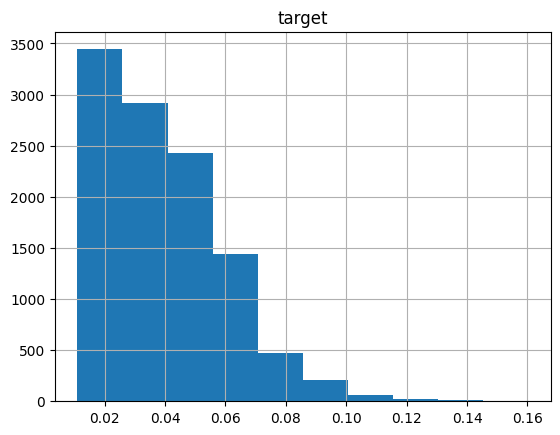

In [ ]:
pd.DataFrame({"target": submission}).hist()